In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import os

# Create results directory in the notebook directory
os.makedirs("results", exist_ok=True)
print("Results directory created at:", os.path.abspath("results"))

Results directory created at: c:\Users\la7tim\Desktop\Internship\FedTinyProp\notebooks\results


In [4]:
import torchvision
import torchvision.transforms as transforms

# CIFAR-100 channel means and stds
C100_MEAN = (0.5071, 0.4865, 0.4409)
C100_STD  = (0.2673, 0.2564, 0.2762)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(C100_MEAN, C100_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(C100_MEAN, C100_STD),
])

# Load CIFAR-100
trainset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test)

# Print dataset info
print(f"Training set size: {len(trainset)}")   # → 50,000
print(f"Test set size:     {len(testset)}")    # → 10,000
print(f"Number of classes: {len(trainset.classes)}")  # → 100


Training set size: 50000
Test set size:     10000
Number of classes: 100


In [5]:
num_clients = 5
partitions = {
    "iid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),   
}


=== Partition Statistics for CIFAR-100 ===

IID Partition:
Total samples: 50000

Per-client distribution:
Client 0: 13986 samples (27.97%)
Client 1: 7037 samples (14.07%)
Client 2: 7700 samples (15.40%)
Client 3: 10093 samples (20.19%)
Client 4: 11184 samples (22.37%)
[Debug] Number of classes: 100
[Debug] Number of clients: 5
[Debug] Processing client 0 with 13986 samples
[Debug] Client 0 has 13986 valid targets
[Debug] Client 0 class counts: [119. 495. 495.   1.   1. 350.   1.   1.  52.   5.   1.   1.   2.   1.
   1. 495. 495. 495.   1. 495.   1. 496.   1. 495.   1.   1.   1. 495.
   1.   1. 486.   1.   1.   1. 487. 344. 495. 496.   1.   1. 496.   1.
   1.   1.   1. 495.   1.   1.   2. 207. 495.   1.   1.   1.   5.   1.
   1.   1.   1.   1.   1. 495. 495. 491. 495.   1. 471. 474.   1.   1.
   1.   1. 495.   1.   1.   1.   1.   1.  29.   1.   1.   1.   1.   1.
 495.   1.   1.   1.   1.   1. 495.   1. 495.   1.   1.   1.   1.   1.
   1.   1.]
[Debug] Processing client 1 with 7037 samp

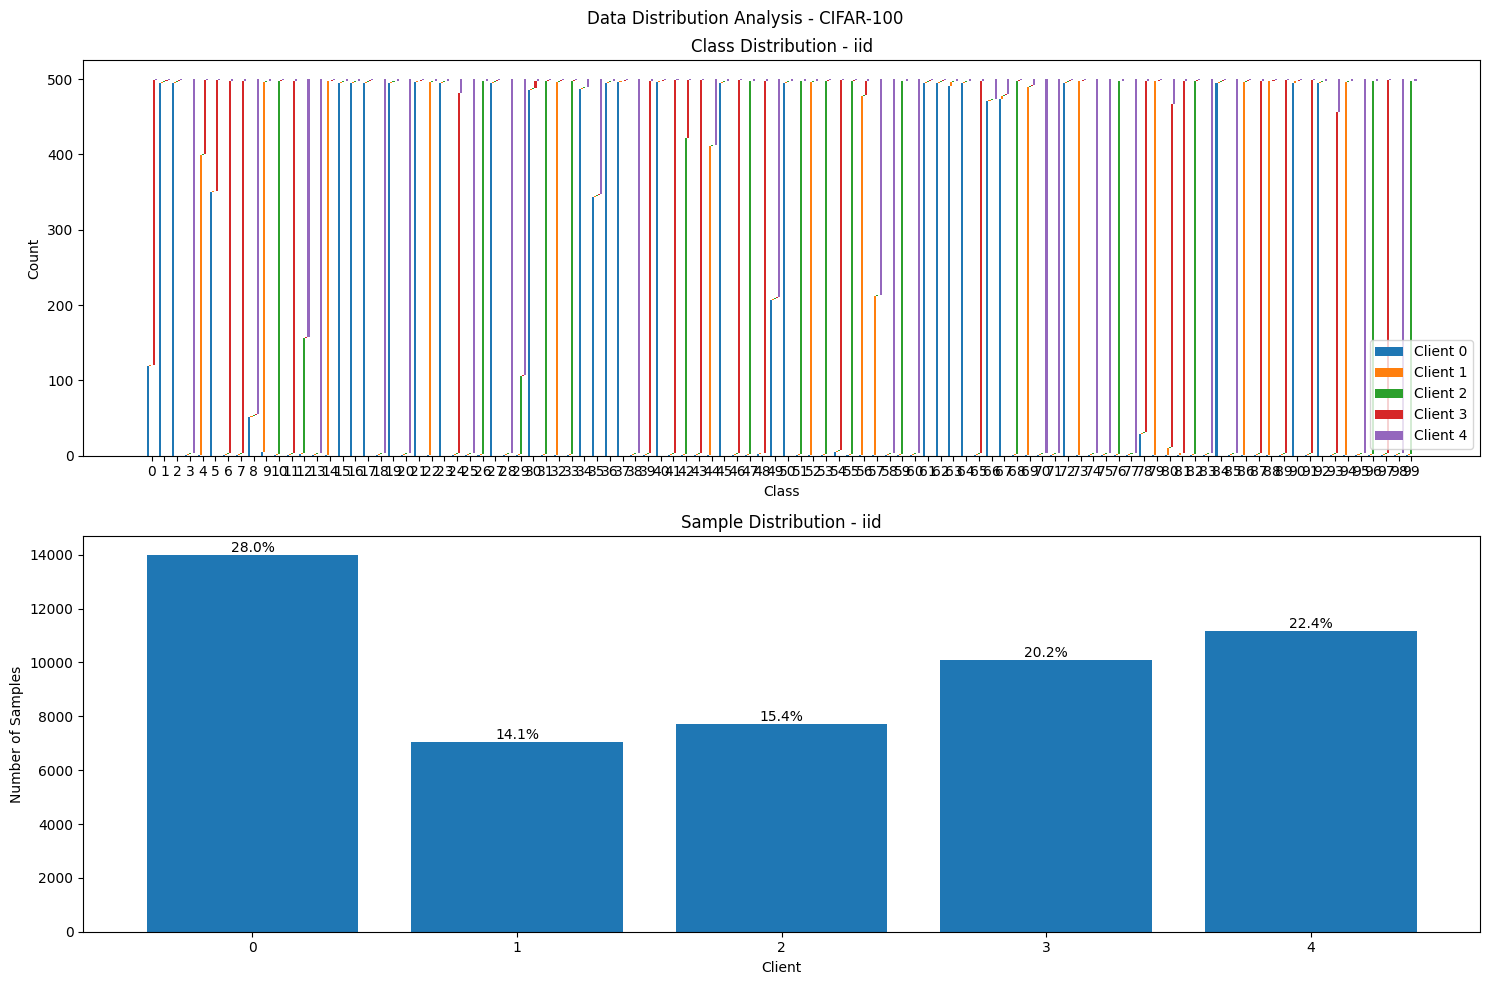

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "CIFAR-100")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "CIFAR-100")
plt.show()

In [7]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("cifar100")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x000002409B202D50>
optimizer: {'type': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}
lr_scheduler: {'type': 'cosine', 'T_max': 100, 'eta_min': 0.0001, 'warmup_epochs': 5, 'warmup_start_lr': 0.001}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
data_augmentation: {'random_crop': True, 'random_horizontal_flip': True, 'random_rotation': 5, 'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2}}
quantization: {'bits': 8, 'enabled': True, 'adaptive': True, 'min_bits': 4, 'max_bits': 16, 'layer_specific': True, 'error_threshold': 0.01, 'momentum': 0.9}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 11


In [8]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Get base config
    config = get_tinyprop_config('cifar100')
    
    # Run training
    model, metrics = federated_training(
        client_datasets=client_datasets,
        model_name='cifar100',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/cifar100_metrics.csv',  # Single CSV file for all partitions
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        save_dir='results',
        save_interval=1,
        use_dense_baseline=True,
        use_fedprox= False,
        fedprox_mu= 0.01,
        use_fedprune=True,
        fedprune_sparsity=0.5
    )
    
    # Print summary statistics
    print(f"\nTraining Summary for {partition_name.upper()}:")
    print(f"Final Accuracy: {metrics['accuracy'][-1]:.4f}")
    print(f"Average Sparsity: {np.mean(metrics['sparsity']):.4f}")
    print(f"Average Compression Ratio: {np.mean(metrics['compression_ratio']):.4f}")
    print(f"Average Effective Compute Ratio: {np.mean(metrics['effective_compute_ratio']):.4f}")
    print(f"Total Communication Cost: {metrics['communication'][-1]/1024:.2f} KB")
    print(f"Total Memory Saved: {metrics['memory_saved'][-1]:.2f} MB")
    
    return model, metrics

# Run training for each partition
partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, metrics = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'metrics': metrics
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue


Starting training for IID partition...

Training on partition: IID

[Training Debug] Initializing clients...
[Training Debug] Client 0 initialized with 13986 samples
[Training Debug] Client 1 initialized with 7037 samples
[Training Debug] Client 2 initialized with 7700 samples
[Training Debug] Client 3 initialized with 10093 samples
[Training Debug] Client 4 initialized with 11184 samples

Round 1/100

[Training Debug] Training client 0

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 1

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 2

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 3

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training cli

Traceback (most recent call last):
  File "C:\Users\la7tim\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\la7tim\AppData\Local\Temp\ipykernel_34068\734655488.py", line 49, in <module>
    model, metrics = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\la7tim\AppData\Local\Temp\ipykernel_34068\734655488.py", line 9, in train_and_analyze_partition
    model, metrics = federated_training(
                     ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\la7tim\Desktop\Internship\FedTinyProp\clients\federated_training.py", line 212, in federated_training
    parameters, num_examples, metrics = client.fit(
                                        ^^^^^^^^^^^
  File "c:\Users\la7tim\Desktop\Internship\FedTinyProp\clients\federated_